In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.stats import pearsonr
from operator import xor

In [3]:
df = pd.read_csv("../data/processed/CA_Fara_500_2019.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8004 entries, 0 to 8003
Data columns (total 93 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CountyName              8004 non-null   object 
 1   GEOID                   8004 non-null   int64  
 2   TotalPopulation         8004 non-null   int64  
 3   ACCESS2_CrudePrev       8004 non-null   float64
 4   ACCESS2_Crude95CI       8004 non-null   object 
 5   ARTHRITIS_CrudePrev     8004 non-null   float64
 6   ARTHRITIS_Crude95CI     8004 non-null   object 
 7   BINGE_CrudePrev         8004 non-null   float64
 8   BINGE_Crude95CI         8004 non-null   object 
 9   BPHIGH_CrudePrev        8004 non-null   float64
 10  BPHIGH_Crude95CI        8004 non-null   object 
 11  BPMED_CrudePrev         8004 non-null   float64
 12  BPMED_Crude95CI         8004 non-null   object 
 13  CANCER_CrudePrev        8004 non-null   float64
 14  CANCER_Crude95CI        8004 non-null   

In [5]:
df.describe()

,GEOID,TotalPopulation,ACCESS2_CrudePrev,ARTHRITIS_CrudePrev,BINGE_CrudePrev,BPHIGH_CrudePrev,BPMED_CrudePrev,CANCER_CrudePrev,CASTHMA_CrudePrev,CERVICAL_CrudePrev,...,LAPOP1_10,LAPOP05_10,LAPOP1_20,LALOWI1_10,LALOWI05_10,LALOWI1_20,TractLOWI,TotalPop,UninsuredPop,MedHouseInc
count,8.004000e+03,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8002.000000,...,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,8004.000000,7963.000000
mean,6.054922e+09,4654.074088,16.017716,19.480210,17.631234,27.052024,67.144140,5.738981,8.674025,82.138178,...,618.569090,2083.846577,599.732134,150.539730,596.667791,143.461144,1561.220640,4907.323963,182.607696,81511.300766
std,2.654240e+07,1955.764393,8.569052,4.657959,2.650999,4.812394,6.376746,1.929911,1.284996,4.408860,...,1385.984127,2079.575521,1376.994123,417.025812,757.719009,410.778015,1141.117173,2253.866377,139.208654,39376.181964
min,6.001400e+09,56.000000,3.500000,2.500000,4.800000,5.700000,10.800000,0.600000,4.900000,46.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7461.000000
25%,6.037263e+09,3369.000000,9.200000,16.300000,16.200000,24.200000,63.800000,4.300000,7.700000,79.700000,...,0.000000,200.750000,0.000000,0.000000,47.000000,0.000000,702.000000,3479.750000,91.000000,52459.000000
50%,6.059053e+09,4422.000000,13.500000,19.000000,17.500000,26.700000,67.500000,5.400000,8.600000,82.700000,...,0.000000,1651.500000,0.000000,0.000000,337.000000,0.000000,1288.000000,4623.500000,154.000000,73632.000000
75%,6.073016e+09,5660.500000,21.400000,22.000000,19.000000,29.500000,71.100000,6.800000,9.500000,85.300000,...,452.000000,3277.000000,370.000000,82.000000,837.000000,68.000000,2156.000000,5935.000000,238.000000,101346.000000
max,6.115041e+09,37452.000000,47.200000,47.900000,35.500000,57.300000,88.800000,19.800000,14.200000,90.900000,...,15859.000000,23517.000000,15859.000000,5886.000000,7909.000000,5886.000000,11639.000000,38754.000000,2937.000000,250001.000000


Population weighted mean function

In [ ]:
def pop_weight(df: pd.DataFrame, col: str): 
    result_name = f"{col}_weighted"
    
    weighted = df.copy()
    weighted["weighted_val"] = weighted[col] * weighted["TotalPopulation"]
    grouped = weighted.groupby("CountyName").agg(
        total_weighted_val = ('weighted_val', 'sum'),
        total_weight = ('TotalPopulation', 'sum')
    )
    
    grouped[result_name] = grouped['total_weighted_val'] / grouped['total_weight']
    return grouped

CountyName
Alameda            11.920411
Alpine              9.500000
Amador             10.667194
Butte              11.581095
Calaveras           9.719189
Colusa             20.256875
Contra Costa       11.714039
Del Norte          15.106770
El Dorado           8.902214
Fresno             21.165075
Glenn              17.819117
Humboldt           10.862730
Imperial           26.252539
Inyo               11.149229
Kern               22.009775
Kings              22.126333
Lake               12.958758
Lassen             15.061453
Los Angeles        19.615178
Madera             22.164631
Marin               8.773245
Mariposa            9.729346
Mendocino          13.124201
Merced             22.496318
Modoc              12.564856
Mono               12.095064
Monterey           21.825514
Napa               12.892480
Nevada              8.293391
Orange             14.614484
Placer              8.820794
Plumas              8.672350
Riverside          17.962400
Sacramento         13.090845
San

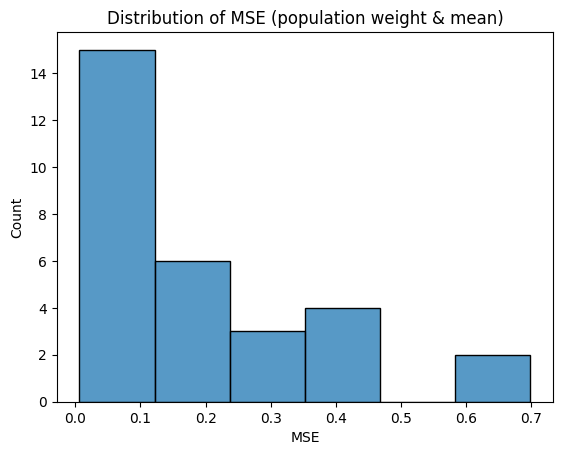

In [ ]:
mses = []
for i in df.columns:
    if re.match(string=i, pattern=r'\S*(Prev)$'):
        pop_weighting = pop_weight(df, i)[f"{i}_weighted"]
        grouped = df.groupby("CountyName").agg({i: "mean"})[i]
        mse = ((grouped - pop_weighting) ** 2).mean()
        mses.append(mse)
        print(f"{i} MSE: {mse}")

ax = sns.histplot(data=mses)
ax.set(xlabel="MSE", ylabel="Count", title="Distribution of MSE (population weight & mean)")
plt.show()

In [40]:
counties = df.groupby("CountyName")

[Text(0.5, 0, 'County'),
 Text(0, 0.5, 'Population'),
 Text(0.5, 1.0, '5 largest counties')]

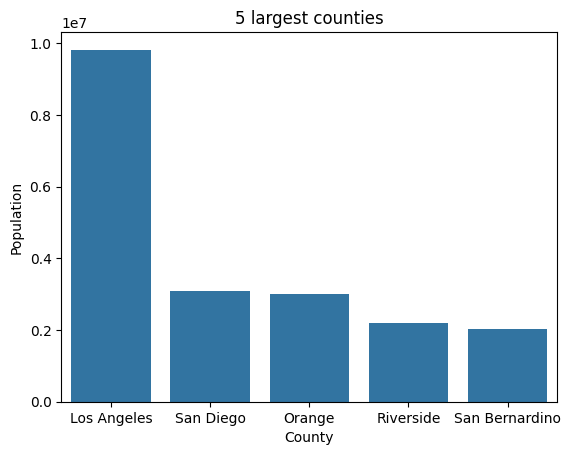

In [41]:
top_population = counties.agg({"TotalPopulation": "sum"}).nlargest(5, columns="TotalPopulation")
ax = sns.barplot(x="CountyName", y="TotalPopulation", data=top_population)
ax.set(xlabel="County", ylabel="Population", title="5 largest counties")

[Text(0.5, 0, 'County'),
 Text(0, 0.5, 'Median Family Income'),
 Text(0.5, 1.0, 'Top 6 Counties by Median Family Income')]

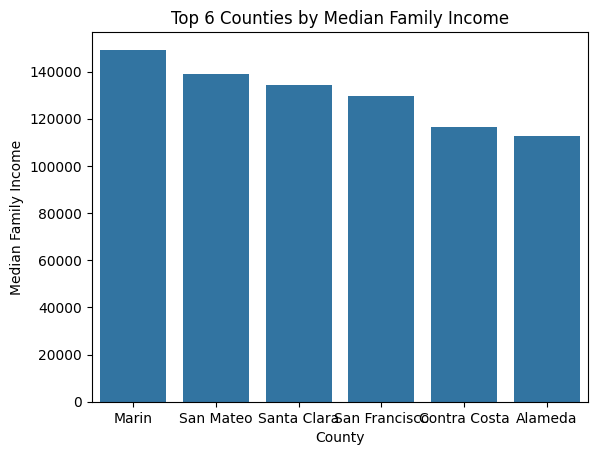

In [42]:
pov_rate = pop_weight(df, "MedianFamilyIncome").nlargest(6, columns="MedianFamilyIncome_weighted")
ax = sns.barplot(data=pov_rate, x="CountyName", y="MedianFamilyIncome_weighted")
ax.set(xlabel="County", ylabel="Median Family Income", title="Top 6 Counties by Median Family Income")

[Text(0.5, 0, 'County'),
 Text(0, 0.5, 'Poverty Rate'),
 Text(0.5, 1.0, 'Top 6 Counties by Poverty Rate (population weighted)')]

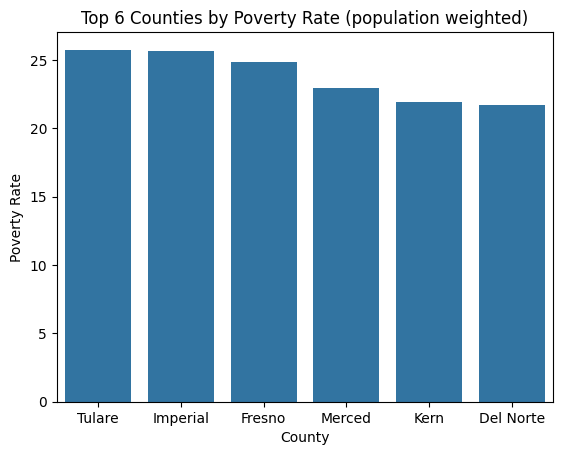

In [43]:
pov_rate = pop_weight(df, "PovertyRate").nlargest(6, columns="PovertyRate_weighted")
ax = sns.barplot(data=pov_rate, x="CountyName", y="PovertyRate_weighted")
ax.set(xlabel="County", ylabel="Poverty Rate", title="Top 6 Counties by Poverty Rate (population weighted)")

[Text(0.5, 0, 'County'),
 Text(0, 0.5, 'Low Access & Low Income at .5/10 mi'),
 Text(0.5, 1.0, 'Top 6 Counties by LALI 0.5/10')]

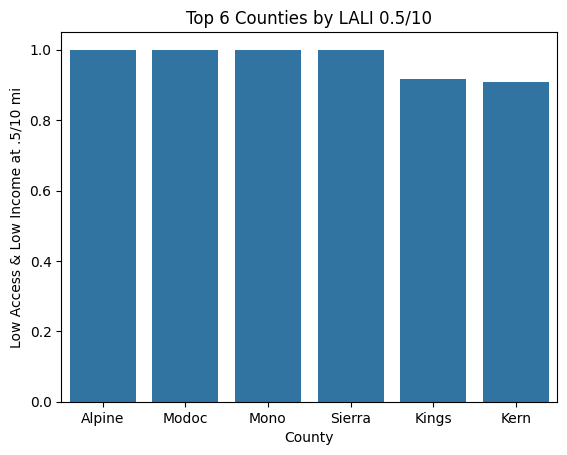

In [44]:
pov_rate = pop_weight(df, "LAhalfand10").nlargest(6, columns="LAhalfand10_weighted")
ax = sns.barplot(data=pov_rate, x="CountyName", y="LAhalfand10_weighted")
ax.set(xlabel="County", ylabel="Low Access & Low Income at .5/10 mi", title="Top 6 Counties by LALI 0.5/10")

Wholistic max and min county for each column

In [45]:
d_cols = []
for i in df.columns:
    if re.match(string=i, pattern=r'\S*(CI)$'):
        d_cols.append(i)
        
d_cols.append("Geolocation")
d_cols.append("GEOID")

In [46]:
no_ci = df.drop(columns=d_cols)

Note: Ignore population and indicator related columns as the formula used to weight was not made with it in mind (no information gain from it anyways)

In [57]:
for i in no_ci.columns.to_list():
    if i !=  "CountyName":
        weighted = pop_weight(df, i)[f"{i}_weighted"]
        max_info = (
            weighted.idxmax(), 
            weighted.max()
            )
        min_info = (
            weighted.idxmin(), 
            weighted.min()
            )
        print(f"{i} --  max: {max_info[0]} ({max_info[1]}), min: {min_info[0]} ({min_info[1]})")

TotalPopulation --  max: Madera (7465.901799622179), min: Alpine (1175.0)
ACCESS2_CrudePrev --  max: Imperial (26.252539420608727), min: Nevada (8.293391316674091)
ARTHRITIS_CrudePrev --  max: Sierra (30.8), min: Santa Clara (15.76291089904706)
BINGE_CrudePrev --  max: Mono (21.103738910012673), min: Fresno (15.573923907786554)
BPHIGH_CrudePrev --  max: Trinity (36.88916291890324), min: Santa Clara (22.801543912862403)
BPMED_CrudePrev --  max: Sierra (75.6), min: Kings (63.49930710802578)
CANCER_CrudePrev --  max: Sierra (9.1), min: Kings (4.765971813677426)
CASTHMA_CrudePrev --  max: Tehama (10.568260246127664), min: Santa Clara (7.576155030022867)
CERVICAL_CrudePrev --  max: Marin (87.44192085068282), min: Tulare (79.52465833972215)
CHD_CrudePrev --  max: Trinity (8.590620919773682), min: Santa Clara (3.7564688641152375)
CHECKUP_CrudePrev --  max: Plumas (74.0231119108312), min: Tulare (66.70027115715581)
CHOLSCREEN_CrudePrev --  max: Marin (89.48748024040347), min: Tulare (81.234559